Initial weights:
w1 = 0.4967141530112327
w2 = -0.13826430117118466
bias = 0.6476885381006925

Final learned parameters:
w1 = 7.2330307997896135
w2 = 7.231170404316738
bias = -3.1433954522817023

Final Predictions
-----------------------------
Input: [0 0]  Probability: 0.0414  Predicted: 0  Expected: 0
Input: [0 1]  Probability: 0.9835  Predicted: 1  Expected: 1
Input: [1 0]  Probability: 0.9835  Predicted: 1  Expected: 1
Input: [1 1]  Probability: 1.0000  Predicted: 1  Expected: 1


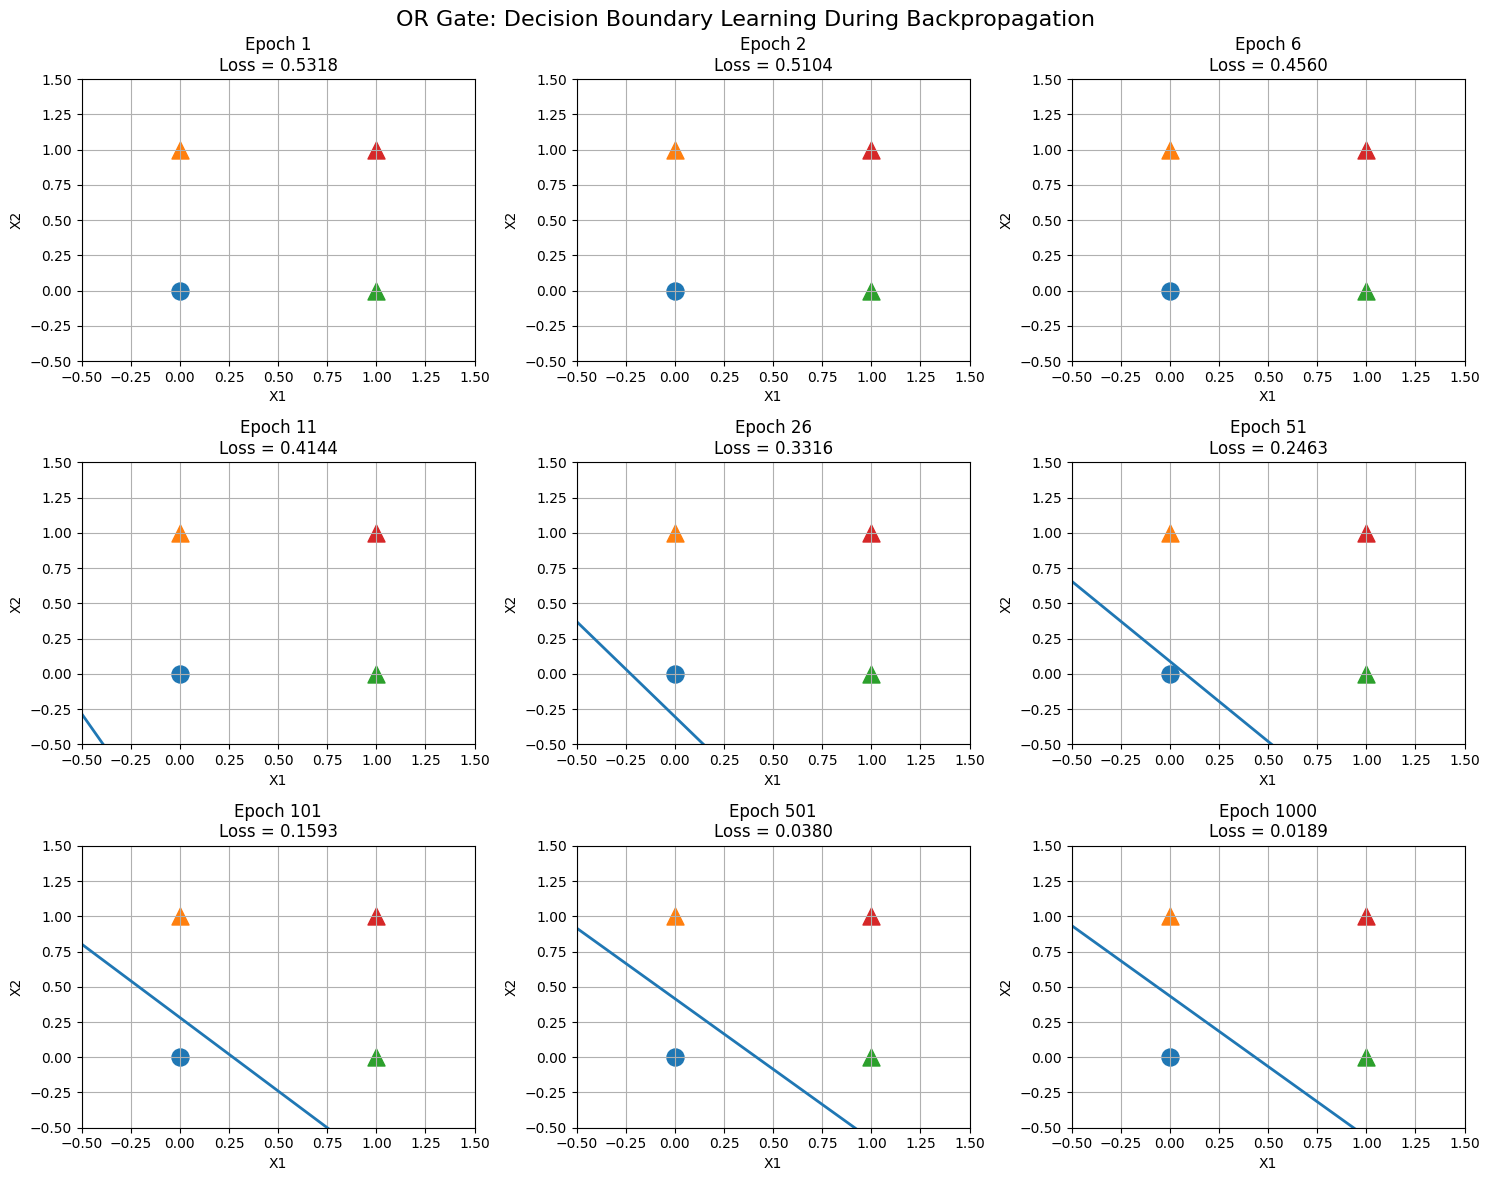

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. OR GATE DATA
# ---------------------------------------------------------

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [0],
    [1],
    [1],
    [1]
], dtype=float)


# ---------------------------------------------------------
# 2. SIGMOID FUNCTION
# ---------------------------------------------------------

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# ---------------------------------------------------------
# 3. INITIALIZE WEIGHTS AND BIAS
# ---------------------------------------------------------

np.random.seed(42)

w1 = np.random.randn()
w2 = np.random.randn()
b = np.random.randn()

print("Initial weights:")
print("w1 =", w1)
print("w2 =", w2)
print("bias =", b)


# ---------------------------------------------------------
# 4. LEARNING PARAMETERS
# ---------------------------------------------------------

learning_rate = 0.5
epochs = 1000

# Store weights for visualization
history = []

# ---------------------------------------------------------
# 5. BACKPROPAGATION TRAINING
# ---------------------------------------------------------

for epoch in range(epochs):

    # -------------------------
    # Forward propagation
    # -------------------------

    z = w1 * X[:, 0] + w2 * X[:, 1] + b

    y_pred = sigmoid(z)

    # -------------------------
    # Calculate error
    # -------------------------

    error = y_pred - y.flatten()

    # Binary cross entropy loss
    loss = -np.mean(
        y.flatten() * np.log(y_pred + 1e-8)
        + (1 - y.flatten()) * np.log(1 - y_pred + 1e-8)
    )

    # -------------------------
    # Backpropagation
    # -------------------------

    dw1 = np.mean(error * X[:, 0])
    dw2 = np.mean(error * X[:, 1])
    db = np.mean(error)

    # -------------------------
    # Update weights
    # -------------------------

    w1 = w1 - learning_rate * dw1
    w2 = w2 - learning_rate * dw2
    b = b - learning_rate * db

    # Store selected epochs
    if epoch in [0, 1, 5, 10, 25, 50, 100, 500, 999]:

        history.append({
            "epoch": epoch + 1,
            "w1": w1,
            "w2": w2,
            "b": b,
            "loss": loss
        })


# ---------------------------------------------------------
# 6. DISPLAY FINAL WEIGHTS
# ---------------------------------------------------------

print("\nFinal learned parameters:")
print("w1 =", w1)
print("w2 =", w2)
print("bias =", b)


# ---------------------------------------------------------
# 7. FINAL PREDICTIONS
# ---------------------------------------------------------

z = w1 * X[:, 0] + w2 * X[:, 1] + b
final_predictions = sigmoid(z)

print("\nFinal Predictions")
print("-----------------------------")

for i in range(len(X)):

    predicted_class = 1 if final_predictions[i] >= 0.5 else 0

    print(
        f"Input: {X[i].astype(int)}  "
        f"Probability: {final_predictions[i]:.4f}  "
        f"Predicted: {predicted_class}  "
        f"Expected: {int(y[i][0])}"
    )


# ---------------------------------------------------------
# 8. VISUALIZE DECISION BOUNDARY
# ---------------------------------------------------------

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

x_boundary = np.linspace(-0.5, 1.5, 100)

for ax, record in zip(axes.ravel(), history):

    w1_plot = record["w1"]
    w2_plot = record["w2"]
    b_plot = record["b"]

    # Decision boundary:
    #
    # w1*x1 + w2*x2 + b = 0
    #
    # Therefore:
    #
    # x2 = -(w1*x1 + b) / w2

    if abs(w2_plot) > 1e-10:

        y_boundary = (
            -(w1_plot * x_boundary + b_plot)
            / w2_plot
        )

        ax.plot(
            x_boundary,
            y_boundary,
            linewidth=2,
            label="Decision boundary"
        )

    # Plot OR-gate data
    for i in range(len(X)):

        if y[i][0] == 0:

            ax.scatter(
                X[i, 0],
                X[i, 1],
                s=150,
                marker="o",
                label="Output 0" if i == 0 else ""
            )

        else:

            ax.scatter(
                X[i, 0],
                X[i, 1],
                s=150,
                marker="^",
                label="Output 1" if i == 1 else ""
            )

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)

    ax.set_xlabel("X1")
    ax.set_ylabel("X2")

    ax.set_title(
        f"Epoch {record['epoch']}\n"
        f"Loss = {record['loss']:.4f}"
    )

    ax.grid(True)

plt.suptitle(
    "OR Gate: Decision Boundary Learning During Backpropagation",
    fontsize=16
)

plt.tight_layout()
plt.show()

# New section

In [ ]:
# OR Gate using a Single Neuron

import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Input data for OR gate
# [0,0] -> 0
# [0,1] -> 1
# [1,0] -> 1
# [1,1] -> 1

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

# Target output
y = np.array([
    [0],
    [1],
    [1],
    [1]
], dtype=np.float32)

# Create neural network
model = Sequential([
    Dense(1, input_shape=(2,), activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

# Train the neural network
model.fit(X, y, epochs=1000, verbose=0)

# Predict OR gate outputs
predictions = model.predict(X)

# Display results
print("\nOR Gate Results:")
print("-----------------------------")

for i in range(len(X)):
    output = 1 if predictions[i][0] >= 0.5 else 0

    print(
        f"Input: {X[i].astype(int)} "
        f"Predicted Probability: {predictions[i][0]:.4f} "
        f"Output: {output} "
        f"Expected: {int(y[i][0])}"
    )

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

OR Gate Results:
-----------------------------
Input: [0 0] Predicted Probability: 0.6504 Output: 1 Expected: 0
Input: [0 1] Predicted Probability: 0.8258 Output: 1 Expected: 1
Input: [1 0] Predicted Probability: 0.7779 Output: 1 Expected: 1
Input: [1 1] Predicted Probability: 0.8992 Output: 1 Expected: 1


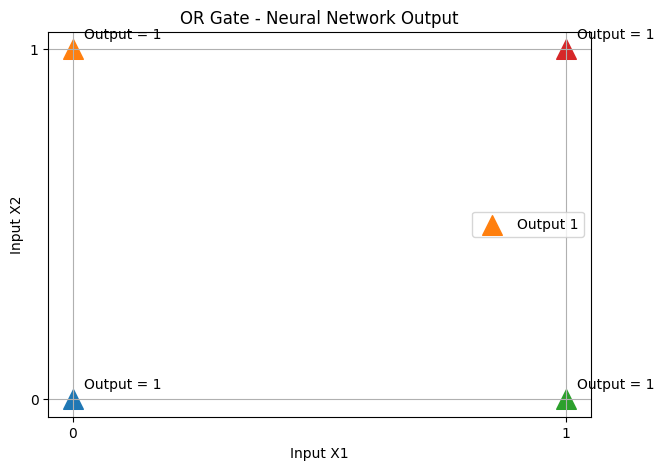

In [ ]:
# Visualize OR gate output

import matplotlib.pyplot as plt

# Convert probabilities to binary predictions
predicted_classes = (predictions >= 0.5).astype(int).flatten()

# Plot the four input combinations
plt.figure(figsize=(7, 5))

for i in range(len(X)):
    if predicted_classes[i] == 0:
        plt.scatter(X[i, 0], X[i, 1], s=200, marker='o',
                    label='Output 0' if i == 0 else "")
    else:
        plt.scatter(X[i, 0], X[i, 1], s=200, marker='^',
                    label='Output 1' if i == 1 else "")

# Add labels
for i in range(len(X)):
    plt.annotate(
        f"Output = {predicted_classes[i]}",
        (X[i, 0], X[i, 1]),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel("Input X1")
plt.ylabel("Input X2")
plt.title("OR Gate - Neural Network Output")
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.grid(True)
plt.legend()
plt.show()